### Compare the models

### 1. Import Python Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import joblib

### 2. Import Data

In [2]:
eval_filepath = '../data/processed/neiss_feature-engineered_eval_data.parquet'
holdout_filepath =  '../data/processed/neiss_feature-engineered_holdout_data.parquet'

In [3]:
eval_data = pd.read_parquet(eval_filepath)
holdout_data = pd.read_parquet(holdout_filepath)

In [4]:
X_eval = eval_data.drop(columns=['Hospitalized'])
y_eval = eval_data['Hospitalized']
X_holdout = holdout_data.drop(columns=['Hospitalized'])
y_holdout = holdout_data['Hospitalized']

### 2. Import the model files

In [5]:
print("Importing trained models from disk...")

log_reg_model = joblib.load('../models/neiss_logistic_regression.joblib')
dt_model = joblib.load('../models/neiss_decision_tree.joblib')
rf_model = joblib.load('../models/neiss_random_forest.joblib')
xgb_model = joblib.load('../models/neiss_XGBoost.joblib')
nb_model = joblib.load('../models/neiss_naive_bayes.joblib')

Importing trained models from disk...


### 3. Draw RUC-AUC Curves

Generating ROC-AUC Curves...


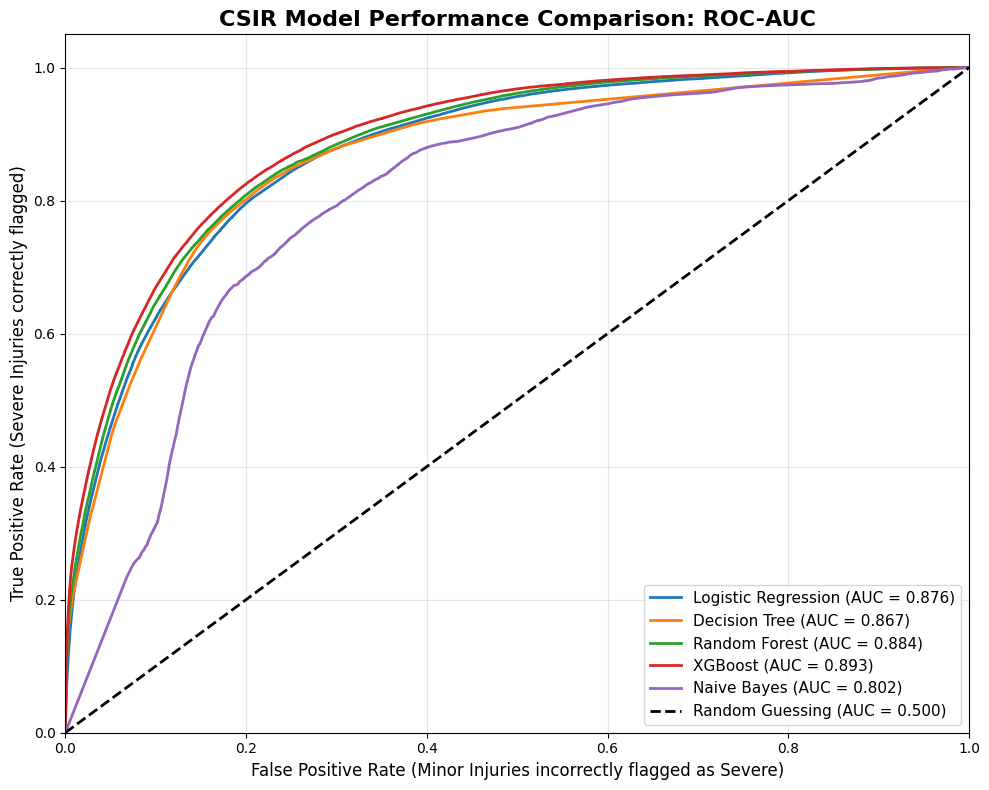

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_model_comparison_roc(models_dict, X_eval, y_eval):
    """
    Takes a dictionary of trained models, calculates their prediction probabilities,
    and plots their ROC curves on a single standardized graph.
    """
    print("Generating ROC-AUC Curves...")
    
    # 1. Set up the plotting canvas
    plt.figure(figsize=(10, 8))
    
    # 2. Iterate through each model in your dictionary
    for model_name, model_pipeline in models_dict.items():
        
        # Step A: Get the probability that the patient is in the Positive Class (e.g., Hospitalized)
        # predict_proba returns two columns [Prob_0, Prob_1]. We want column index 1.
        y_prob = model_pipeline.predict_proba(X_eval)[:, 1]
        
        # Step B: Calculate the False Positive Rate (fpr) and True Positive Rate (tpr)
        fpr, tpr, thresholds = roc_curve(y_eval, y_prob)
        
        # Step C: Calculate the Area Under the Curve (AUC)
        roc_auc = auc(fpr, tpr)
        
        # Step D: Plot the line for this specific model
        plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')

    # 3. Plot the "Coin Flip" Baseline (Random Guessing)
    plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Random Guessing (AUC = 0.500)')

    # 4. Format the Graph for Professional Presentation
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Minor Injuries incorrectly flagged as Severe)', fontsize=12)
    plt.ylabel('True Positive Rate (Severe Injuries correctly flagged)', fontsize=12)
    plt.title('CSIR Model Performance Comparison: ROC-AUC', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)
    
    # 5. Display the Graph
    plt.tight_layout()
    plt.show()

# --- HOW TO USE THIS IN YOUR SCRIPT ---
# First, collect the models you trained earlier into a dictionary:
trained_models = {
     "Logistic Regression": log_reg_model,
     "Decision Tree": dt_model,
     "Random Forest": rf_model,
     "XGBoost": xgb_model,
     "Naive Bayes": nb_model
 }

# Then, run the function using your Validation (Eval) dataset:
plot_model_comparison_roc(trained_models, X_eval, y_eval)